In [1]:
import json

from models.reactors.reactor import Reactor
from models.reactors.iso_reactor import IsoReactor

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.reactor_utils import plot_reactor_solutions

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [2]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)

In [3]:
# Coarse mesh and fixed k and neutron cross sections
Ns_coarse = [15, 15, 30]
cfg_coarse = generate_config(data, *Ns_coarse)

reactor_coarse = Reactor(cfg_coarse)
reactor_coarse.set_variable_k(False)
reactor_coarse.set_variable_neutron_data(False)

# Fine mesh and full variability
Ns = [30, 30, 60]
cfg_fine = generate_config(data, *Ns)

reactor_fine = Reactor(cfg_fine)
reactor_fine.set_variable_k(True)
reactor_fine.set_variable_neutron_data(True)

# Solve iteratively
solver = Solver([reactor_coarse, reactor_fine], iterate = True)
solver.fsolve()

Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
Solving Heat pipe initial values
fsolve message: The solution converged.
final residual L2 norm: 2.076e-06
Running iteration 1 ...
fsolve message: The solution converged.
final residual L2 norm: 3.629e-05
Running iteration 2 ...
fsolve message: The solution converged.
final residual L2 norm: 8.527e-05


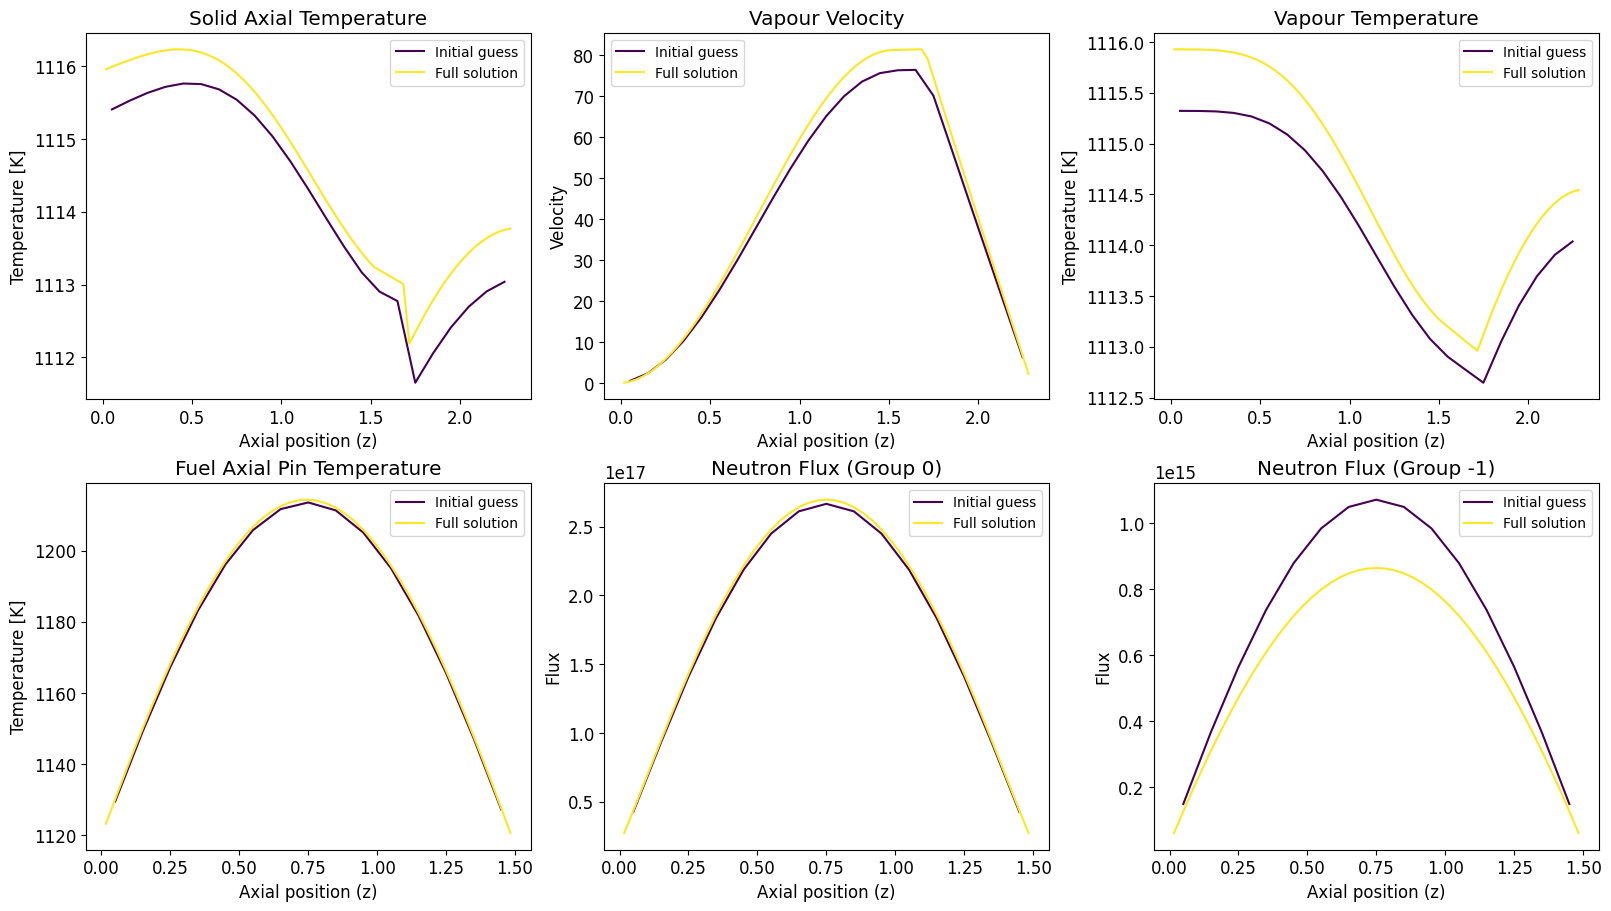

In [6]:
# Plot the coarse solution and the finer solution and full variability
plot_reactor_solutions(solver, labels=["Initial guess", "Full solution"])